In [105]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 128
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:41: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(alphas[0])
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:41: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWa

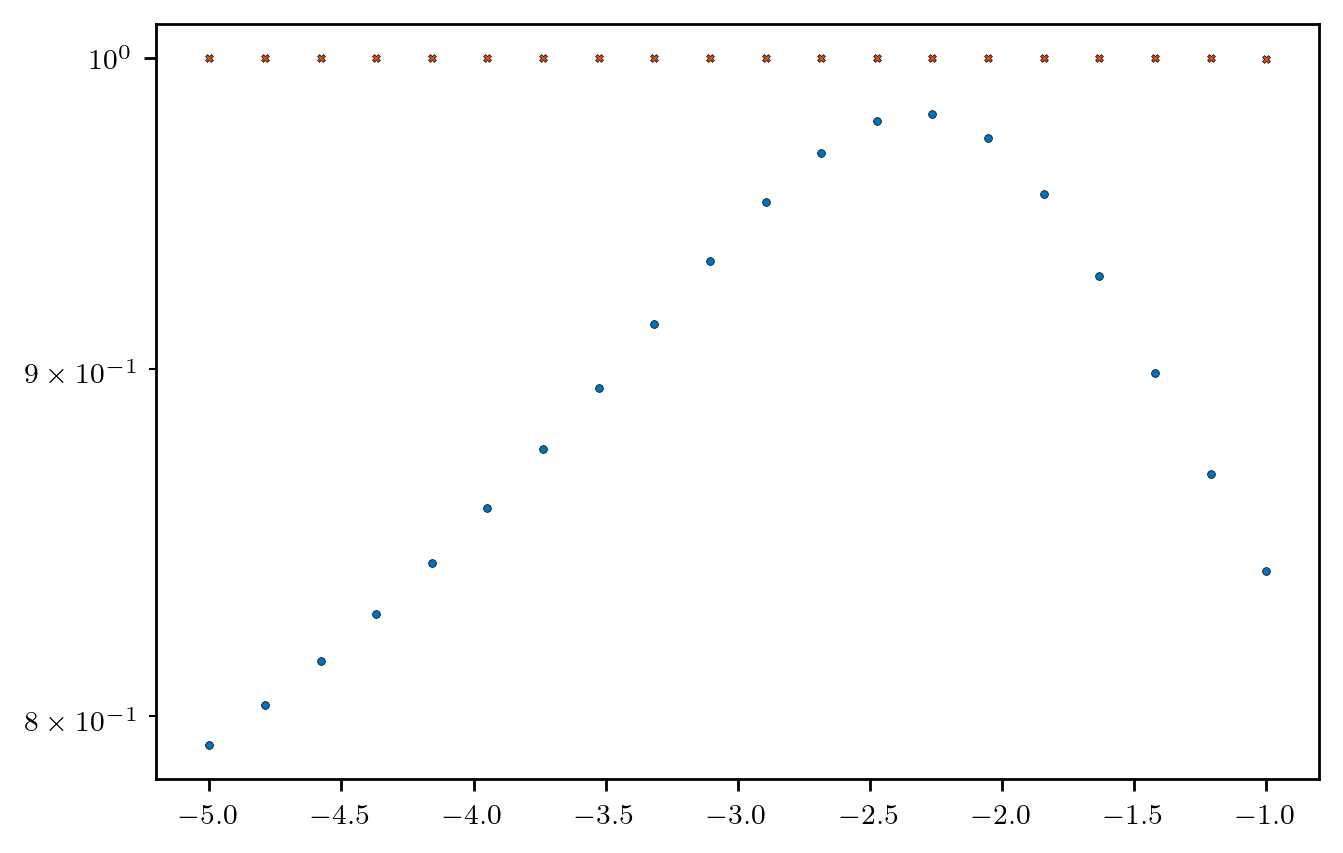

In [106]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1.,)))
energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))

specs = []
Pspecs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    _km, _fekm, width = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='center',
            cut_excess=True, nan_small=False)
    Pspecs.append((_km, _fekm))

    lags = arevalo_spectra.k_to_discrete_lags(_km, N, L)
    km, fekm = arevalo_spectra.modal_spectrum(f, lenn=phys_dims, lags=lags, mode='wrap')
    specs.append((km, fekm))

    e_parsevals = np.nansum(statistics_base.kern(km, D, width, dk) * fekm * (dk/twopi)**D)

    # * (dk/twopi)**D
    plt.scatter(alphas[i], e_parsevals, marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    plt.scatter(alphas[i], energies[i], marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')
    #assert np.isclose(e_parsevals / energies[i], 1., rtol=0.001), e_parsevals / energies[i]

plt.yscale('log')
#plt.ylim((9e-1, 1.1e0))

In [107]:
cols = plt.cm.Greys(np.linspace(0.5, 1., NUM))

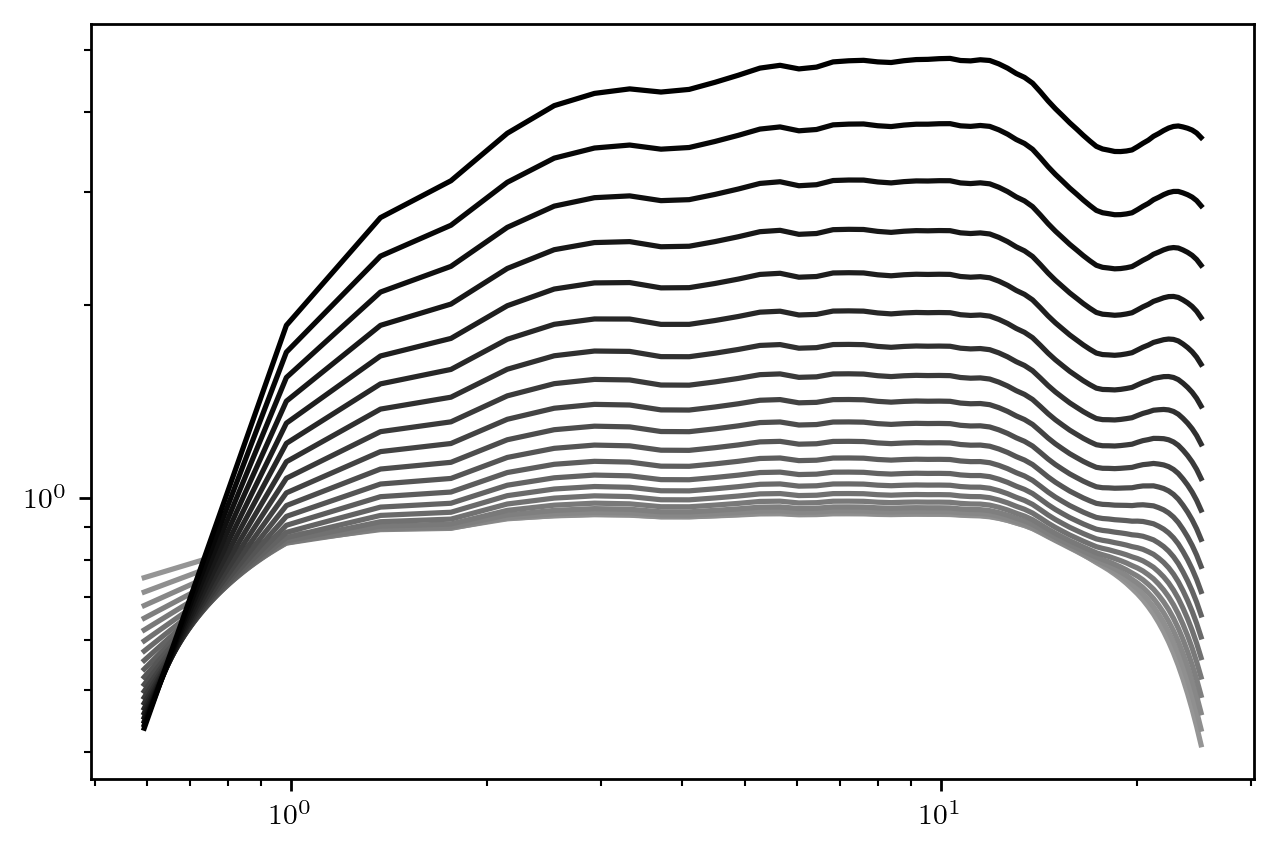

In [108]:
bias = []

for i in range(len(specs)):
    pk, pfek = Pspecs[i]
    ak, afek = specs[i]
    plt.loglog(ak, afek / pfek, color=cols[i])
    bias.append((ak, afek/pfek))

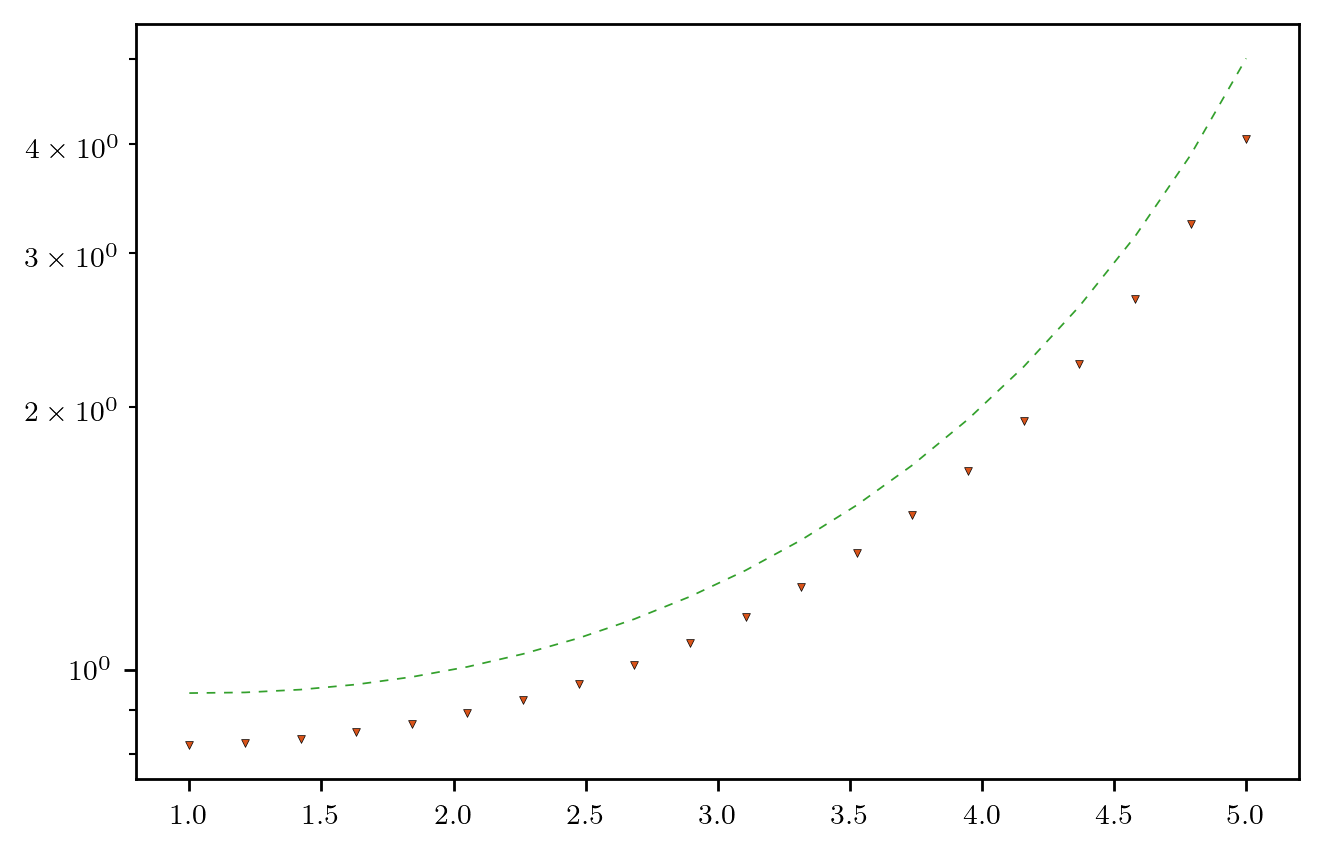

In [109]:
from scipy.special import gamma
aa = -alphas
scaling = 2.**(aa/2.) * gamma(D/2. + 2. - aa/2.) / gamma(D/2. + 2.)
plt.plot(-alphas, scaling - 0., linewidth=0.5, color=c[2], linestyle=(0,(5,5)), zorder=0)

for i in range(len(specs)):
    pk, pfek = Pspecs[i]
    ak, afek = specs[i]
    plt.scatter(-alphas[i], np.nanmean(afek * (dk/twopi)**D * np.sum(np.ones(grid_dims) * dx**D) / pfek), marker='v', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

plt.yscale('log')
#plt.ylim((1e-1, 1e3))

In [110]:
IDX = 13

from scipy.special import jv
import sympy as sp
sp.init_printing(use_latex='mathjax')

k = sp.symbols('k', postive=True, real=True)

a = -alphas[IDX]
print(a)
#a = sp.symbols('a', postive=True, real=True)

sp_kmin = (2.*sp.pi/L)
sp_kmax = (sp.pi*N/L)

sp_E = sp.Piecewise(
    (0, k < sp_kmin),
    (0, k > sp_kmax),
    (k**(-a), True)
)

sig = sp.integrate(2. * (2. * sp.pi * k * sp_E) / (2.*sp.pi)**2, (k, 0., sp.oo))
Ef = sp_E / sig

s = sp.symbols('s', real=True, positive=True)
xi = 1e-3

Hk = k**2 * s**2 * xi * sp.exp(- k**2 * s**2 / 2.)

from scipy.special import gamma as G

S_D = 2.*sp.pi**(D/2)/G(D/2)
norm = 1./(2.*sp.pi)**D

Vs_num = 2. * norm * sp.integrate((S_D * k**(D-1)) * Ef * sp.Abs(Hk)**2, (k, 0., sp.oo))
Vs_denom = 2. * norm * sp.integrate((S_D * k**(D-1)) * sp.Abs(Hk)**2, (k, 0., sp.oo))
Vs = Vs_num / Vs_denom

display(Vs_num)
display(Vs_denom)
display(Vs)


3.7368421052631575


    ⎛                       3.73684210526316  1.73684210526316  ⎛             
0.5⋅⎝- 4.84671434253897e-8⋅π                ⋅s                ⋅γ⎝1.13157894736
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                                              

                        2  2⎞                        3.73684210526316  1.73684
842, 0.016211389382774⋅π ⋅s ⎠ + 4.84671434253897e-8⋅π                ⋅s       
──────────────────────────────────────────────────────────────────────────────
                           2                                                  
                          π                                                   

210526316  ⎛                                    2  2⎞⎞
         ⋅γ⎝1.13157894736842, 66.4018509118425⋅π ⋅s ⎠⎠
──────────────────────────────────────────────────────
                                           

        -1.0
1.0e-6⋅π    
────────────
      2     
     s      

          -1.0  2 ⎛                       3.73684210526316  1.73684210526316  
500000.0⋅π    ⋅s ⋅⎝- 4.84671434253897e-8⋅π                ⋅s                ⋅γ

⎛                                     2  2⎞                        3.736842105
⎝1.13157894736842, 0.016211389382774⋅π ⋅s ⎠ + 4.84671434253897e-8⋅π           

26316  1.73684210526316  ⎛                                    2  2⎞⎞
     ⋅s                ⋅γ⎝1.13157894736842, 66.4018509118425⋅π ⋅s ⎠⎠

/tmp/ipykernel_10416/1192238990.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  plt.scatter(_k, num/denom, marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')


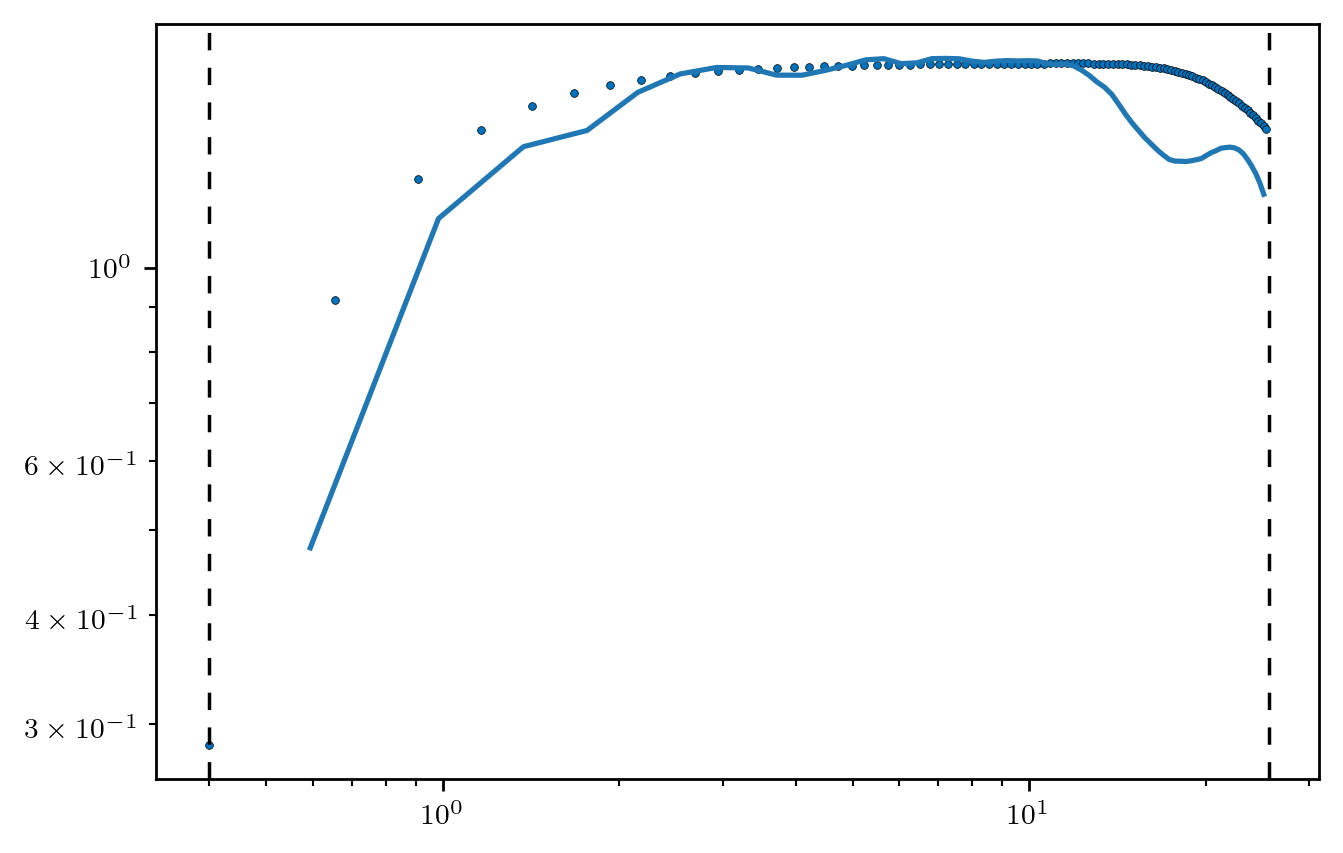

In [111]:
lam_E = sp.lambdify(k, Ef, modules=['scipy', 'numpy'])
lam_V = sp.lambdify(s, Vs, modules=['scipy', 'numpy'])
for _k in np.linspace(2.*np.pi/L, np.pi*N/L, 100):
    _s = np.sqrt(2.) / _k
    num = lam_V(_s)
    denom = lam_E(_k)
    plt.scatter(_k, num/denom, marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

plt.loglog(bias[IDX][0], bias[IDX][1])

plt.loglog()

plt.axvline(2.*np.pi/L, color='black', linewidth=1., linestyle=(0,(5,5)))
plt.axvline(np.pi*N/L, color='black', linewidth=1., linestyle=(0,(5,5)))

In [118]:
IDX = 13

from scipy.special import jv
import sympy as sp
sp.init_printing(use_latex='mathjax')

k = sp.symbols('k', postive=True, real=True)

a = -alphas[IDX]
print(a)
#a = sp.symbols('a', postive=True, real=True)

sp_kmin = (2.*sp.pi/L)
sp_kmax = (sp.pi*N/L)

sp_E = sp.Piecewise(
    (0, k < sp_kmin),
    (0, k > sp_kmax),
    (k**(-a), True)
)

sig = sp.integrate(2. * (2. * sp.pi * k * sp_E) / (2.*sp.pi)**2, (k, 0., sp.oo))
Ef = sp_E / sig

s = sp.symbols('s', real=True, positive=True)
xi = 1e-3

Hk = k**2 * s**2 * xi * sp.exp(- k**2 * s**2 / 2.)

from scipy.special import gamma as G

S_D = 2.*sp.pi**(D/2)/G(D/2)
norm = 1./(2.*sp.pi)**D

Vs_num = 2. * norm * sp.integrate((S_D * k**(D-1)) * Ef * sp.Abs(Hk)**2, (k, 0., sp.oo))
Vs_denom = 2. * norm * sp.integrate((S_D * k**(D-1)) * sp.Abs(Hk)**2, (k, 0., sp.oo))
Vs = Vs_num / Vs_denom

display(Vs_num)
display(Vs_denom)
display(Vs)

Es = Ef.subs({k: sp.sqrt(2.) / s})

Vs_num2 = 2. * norm * Es * sp.integrate((S_D * k**(D-1)) * sp.Abs(Hk)**2, (k, 0., sp.oo))
Vs_denom2 = 2. * norm * sp.integrate((S_D * k**(D-1)) * sp.Abs(Hk)**2, (k, 0., sp.oo))
Vs2 = Vs_num2 / Vs_denom2

display(Vs_num2)
display(Vs_denom2)
display(Vs2)

display(Vs/Vs2)

3.7368421052631575


    ⎛                       3.73684210526316  1.73684210526316  ⎛             
0.5⋅⎝- 4.84671434253897e-8⋅π                ⋅s                ⋅γ⎝1.13157894736
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                                              

                        2  2⎞                        3.73684210526316  1.73684
842, 0.016211389382774⋅π ⋅s ⎠ + 4.84671434253897e-8⋅π                ⋅s       
──────────────────────────────────────────────────────────────────────────────
                           2                                                  
                          π                                                   

210526316  ⎛                                    2  2⎞⎞
         ⋅γ⎝1.13157894736842, 66.4018509118425⋅π ⋅s ⎠⎠
──────────────────────────────────────────────────────
                                           

        -1.0
1.0e-6⋅π    
────────────
      2     
     s      

          -1.0  2 ⎛                       3.73684210526316  1.73684210526316  
500000.0⋅π    ⋅s ⋅⎝- 4.84671434253897e-8⋅π                ⋅s                ⋅γ

⎛                                     2  2⎞                        3.736842105
⎝1.13157894736842, 0.016211389382774⋅π ⋅s ⎠ + 4.84671434253897e-8⋅π           

26316  1.73684210526316  ⎛                                    2  2⎞⎞
     ⋅s                ⋅γ⎝1.13157894736842, 66.4018509118425⋅π ⋅s ⎠⎠

                                      ⎛⎧                                      
                                      ⎜⎪                 0                   f
                     1.73684210526316 ⎜⎪                                      
4.84671434253897e-8⋅π                ⋅⎜⎨                                      
                                      ⎜⎪                   3.73684210526316   
                                      ⎜⎪0.273872999716349⋅s                   
                                      ⎝⎩                                      
──────────────────────────────────────────────────────────────────────────────
                                                                              
                                                                              

   1.4142135623731                        1.4142135623731                     
or ─────────────── > 8.14873308630504⋅π ∨ ─────────────── < 0.127323954473516⋅
          s                                      s 

        -1.0
1.0e-6⋅π    
────────────
      2     
     s      

                                     ⎛⎧                                       
                                     ⎜⎪                 0                   fo
                    2.73684210526316 ⎜⎪                                       
0.0484671434253897⋅π                ⋅⎜⎨                                       
                                     ⎜⎪                   3.73684210526316    
                                     ⎜⎪0.273872999716349⋅s                    
                                     ⎝⎩                                       

  1.4142135623731                        1.4142135623731                      
r ─────────────── > 8.14873308630504⋅π ∨ ─────────────── < 0.127323954473516⋅π
         s                                      s                             
                                                                              
                                                                              
                                 otherwise         

                                                                              
                                                                              
                  -3.73684210526316  2 ⎛                       3.7368421052631
10316267.1587959⋅π                 ⋅s ⋅⎝- 4.84671434253897e-8⋅π               
                                                                              
                                                                              
                                                                              

                                                                              
                                                                              
6  1.73684210526316  ⎛                                     2  2⎞              
 ⋅s                ⋅γ⎝1.13157894736842, 0.016211389382774⋅π ⋅s ⎠ + 4.846714342
                                                                              
                                                   

In [126]:
D = sp.symbols('D', positive=True, real=True)
S_D = 2.*sp.pi**(D/2)/sp.gamma(D/2)
norm = 1./(2.*sp.pi)**D
xi = sp.symbols('xi', positive=True, real=True)
Hk = k**2 * s**2 * xi * sp.exp(- k**2 * s**2 / 2.)
Vs_denom = 2. * sp.integrate((S_D * k**(D-1)) * sp.Abs(Hk)**2, (k, 0., sp.oo))
display(Vs_denom)

                       D             
     D               - ─ - 1         
     ─                 2             
     2  2  2 ⎛     2⎞         ⎛D    ⎞
2.0⋅π ⋅s ⋅ξ ⋅⎝1.0⋅s ⎠       ⋅Γ⎜─ + 2⎟
                              ⎝2    ⎠
─────────────────────────────────────
                  ⎛D⎞                
                 Γ⎜─⎟                
                  ⎝2⎠                

In [113]:
# from scipy.special import jv
# import sympy as sp
# sp.init_printing(use_latex='mathjax')

# k, l = sp.symbols('k l', positive=True, real=True)

# s = sp.symbols('s', real=True, positive=True)
# D = sp.symbols('D', integer=True, positive=True)
# xi = sp.symbols('xi', real=True, positive=True)

# a = sp.symbols('a', positive=True, real=True)
# Kl, Kh = sp.symbols('Kl Kh', positive=True, real=True)

# a = -alphas[IDX]
# print('POWERLAW', a)
# Kl = np.nanmin(k_true)
# Kh = np.nanmax(k_true)
# D = 2
# xi = 1e-3

# E = sp.Piecewise(
#     (1, k < Kl),
#     (0, k >= Kh),
#     (k**(-a), True)
# )

# S_D = 2*sp.pi**(D/2)/sp.gamma(D/2)
# norm = 1/(2*sp.pi)**D

# E_H = sp.Abs(k**2 * s**2 * xi * sp.exp(-k**2 * s**2 / 2))**2

# dk = 2.*sp.pi/L

# VAR_s = dk**D * norm * S_D * sp.integrate(E * E_H * k**(D - 1), (k, 0, sp.oo))

# display(VAR_s)
